# 03 — Edit distance with Real Penalty (ERP)

**What it measures.** ERP keeps the edit-distance structure of EDR but replaces its
0/1 costs with *real* distances. A match costs the actual difference `|x_i - y_j|`, and
a gap — a sample that has no partner — costs the distance of that sample to a fixed
constant `g`, the "gap element":

```
D[i, j] = min( D[i-1, j-1] + |x_i - y_j|,   # match
               D[i-1, j]   + |x_i - g|,     # gap in y  (x_i matched against g)
               D[i,   j-1] + |y_j - g| )    # gap in x  (y_j matched against g)
```

with `D[0, 0] = 0` and borders `D[i, 0] = sum_{k<=i} |x_k - g|`,
`D[0, j] = sum_{k<=j} |y_k - g|`. We use **`g = 0`**, the usual choice: our sensor
signals oscillate around zero, so "no observation" is naturally represented by the
zero level, and a gap then costs exactly the magnitude of the unmatched sample.

**Why this makes ERP a metric.** Because a gap is charged against the *same* constant
`g` for both series, the cost of an alignment behaves like an L1 distance between two
padded sequences. ERP therefore satisfies non-negativity, symmetry, identity of
indiscernibles *and the triangle inequality* — it is a true metric, which DTW and EDR
are not (both let you "skip" arbitrary amounts of signal for free, so
`d(x, z) <= d(x, y) + d(y, z)` can be violated). This matters in practice: metric
distances can be used with metric indexing structures and clustering algorithms that
assume the triangle inequality holds.

**What sets ERP apart from DTW/EDR.** DTW never leaves a sample unmatched (it warps
instead), EDR pays a flat 1 for every gap, ERP pays `|x_i - g|` — so skipping a large
excursion of the signal is expensive, while skipping a stretch near the baseline is
cheap. It is the "middle ground" of the three: elastic in time like DTW, edit-based like
EDR, and magnitude-aware in both its matches and its gaps.

In [1]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
# Same shared dataset again — identical signals in all four notebooks.
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

G = 0.0  # the gap element; documented in the markdown cell above
print(f"gap element g = {G}   |  mean of reference = {reference.mean():.3f}")

gap element g = 0.0   |  mean of reference = 0.442


In [3]:
def erp_cost_matrix(x: np.ndarray, y: np.ndarray, g: float = 0.0) -> np.ndarray:
    """Accumulated ERP cost matrix for two 1-D series.

    Parameters
    ----------
    x, y : np.ndarray
        The two series, of length ``n`` and ``m``.
    g : float
        The gap element. An unmatched sample is charged its distance to ``g``.

    Returns
    -------
    np.ndarray
        Matrix ``D`` of shape ``(n + 1, m + 1)``. The border rows accumulate the
        gap costs, i.e. the price of aligning a prefix against gaps only.
    """
    n, m = len(x), len(y)
    match = np.abs(x[:, None] - y[None, :])  # cost of pairing x_i with y_j
    gap_x = np.abs(x - g)                    # cost of leaving x_i unmatched
    gap_y = np.abs(y - g)                    # cost of leaving y_j unmatched

    D = np.zeros((n + 1, m + 1))
    D[1:, 0] = np.cumsum(gap_x)
    D[0, 1:] = np.cumsum(gap_y)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i, j] = min(D[i - 1, j - 1] + match[i - 1, j - 1],
                          D[i - 1, j] + gap_x[i - 1],
                          D[i, j - 1] + gap_y[j - 1])
    return D


def erp_distance(x: np.ndarray, y: np.ndarray, g: float = 0.0) -> float:
    """ERP distance between ``x`` and ``y``."""
    return float(erp_cost_matrix(x, y, g)[-1, -1])

In [4]:
def erp_path(D: np.ndarray) -> list[tuple[int, int]]:
    """Back-track one optimal alignment path through an ERP cost matrix."""
    i, j = D.shape[0] - 1, D.shape[1] - 1
    path = []
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        step = int(np.argmin([D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]]))
        if step == 0:
            i, j = i - 1, j - 1
        elif step == 1:
            i -= 1
        else:
            j -= 1
    return path[::-1]

In [5]:
# Sanity check on the metric properties, on short slices so it stays quick.
a, b, c = reference[:60], dataset["noisy"][:60], dataset["phase_shifted"][:60]

print("d(a, a)            =", erp_distance(a, a, G))                    # identity -> 0
print("d(a, b) == d(b, a) :", np.isclose(erp_distance(a, b, G), erp_distance(b, a, G)))
print("triangle: d(a,c) <= d(a,b) + d(b,c) ->",
      f"{erp_distance(a, c, G):.3f} <= "
      f"{erp_distance(a, b, G) + erp_distance(b, c, G):.3f}")

d(a, a)            = 0.0
d(a, b) == d(b, a) : True
triangle: d(a,c) <= d(a,b) + d(b,c) -> 45.248 <= 70.011


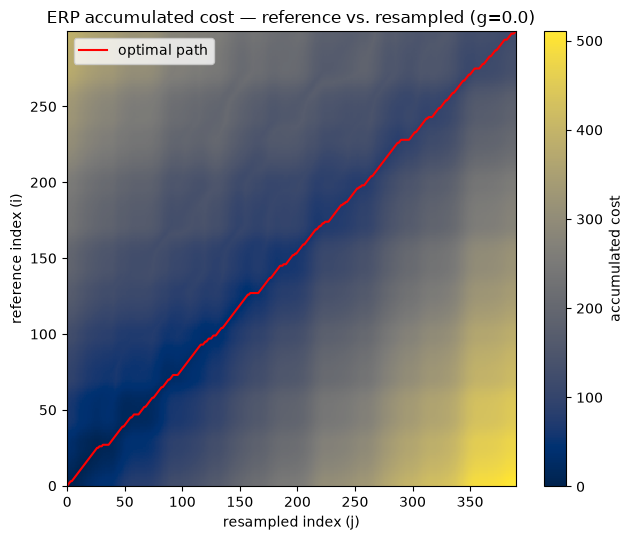

In [6]:
# Visualization: DP matrix heatmap in the same style as notebooks 01-02,
# for the same pair used in notebook 01 (reference vs. resampled).
D_demo = erp_cost_matrix(reference, dataset["resampled"], G)
path_demo = erp_path(D_demo)

plotting.plot_cost_matrix(
    D_demo[1:, 1:],
    path=path_demo,
    title=f"ERP accumulated cost — reference vs. resampled (g={G})",
    xlabel="resampled index (j)",
    ylabel="reference index (i)",
    cbar_label="accumulated cost",
    cmap="cividis",
)

In [7]:
# Distance from `reference` to every variant.
# `g_sensitivity` re-runs everything with a different gap element to show that the
# choice of `g` shifts the price of gaps (and therefore the ranking) — g = 0 is a
# choice, not a law.
erp_table = pd.DataFrame({
    "erp_g0": [erp_distance(reference, dataset[name], 0.0) for name in variants],
    "erp_g_mean": [erp_distance(reference, dataset[name], float(reference.mean()))
                   for name in variants],
}, index=variants)
erp_table.index.name = "variant"
erp_table.sort_values("erp_g0")

,erp_g0,erp_g_mean
variant,,
resampled,120.185,117.348
noisy,124.208,124.979
phase_shifted,130.045,116.445
reversed,187.117,200.880
unrelated,340.040,418.406
amplitude_scaled,393.901,393.901


## Conclusion

ERP calls `resampled` (120.2), `noisy` (124.2) and `phase_shifted` (130.0) similar and
almost indistinguishable from each other, then `reversed` (187.1), and finally
`unrelated` (340.0) and `amplitude_scaled` (393.9). The top of that list is the
signature of ERP: because gaps are charged `|x_i - g|` rather than a flat 1, skipping
samples near the baseline is cheap while skipping large excursions is not — and a
doubled amplitude is expensive twice over, both to match and to skip. That is why
`amplitude_scaled` overtakes even the structurally `unrelated` step signal, which DTW
ranked the other way round.

The gap element is a modelling choice, and the second column shows what it buys: moving
from `g=0` to `g=mean(reference)` makes `unrelated` markedly worse (340 -> 418) and
`phase_shifted` slightly better, because it changes what "no observation" is worth.
`amplitude_scaled` is identical in both columns (393.901) — a useful hint that its
optimal path contains no gaps at all: for two equal-length series it is cheaper to match
everything 1:1 than to pay any gap, so `g` never enters the sum. The metric check above
behaves as advertised: `d(a, a) = 0`, symmetry holds exactly, and the triangle
inequality holds with room to spare — properties DTW and EDR cannot offer, and the
reason ERP is the one of the three you can safely hand to a metric index or a
distance-based clustering algorithm.